# 📊 Notebook 1: Descriptive Statistics – The Language of Data

Welcome! 🎉  
Before we dive into Machine Learning and Deep Learning, we need to **understand data**.  

Statistics is the **language of data**.  
Think of it as the alphabet 🅰️ that helps us read, interpret, and tell stories about numbers.

In this notebook, we’ll explore:  
✅ Mean, Median, Mode  
✅ Variance & Standard Deviation  
✅ Skewness & Kurtosis  
✅ Outliers (IQR Method)  

Each concept will include:  
- Explanation (simple words)  
- Example + Counter-example  
- Visualization (plots)  
- ML/DL connection  

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set(style="whitegrid")

## 📌 Mean, Median, Mode

Mean: 50.90376049262916
Median: 50.053458979122134
Mode: 3


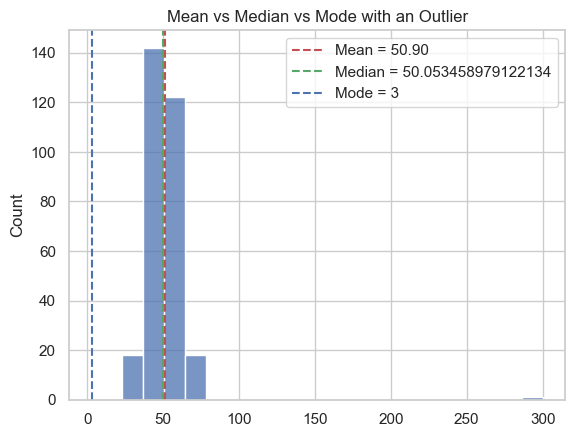

In [3]:
# Example dataset with outlier
# data = [2, 3, 3, 5, 100]
data = np.random.normal(loc=50, scale=10, size=300).tolist()
data.append(300)  # adding an outlier

mean_val = np.mean(data)
median_val = np.median(data)
mode_val = 3  # manually (most common value)

print("Mean:", mean_val)
print("Median:", median_val)
print("Mode:", mode_val)

# Visualization
sns.histplot(data, bins=20, kde=False)
plt.axvline(mean_val, color='r', linestyle='--', label=f"Mean = {mean_val:.2f}")
plt.axvline(median_val, color='g', linestyle='--', label=f"Median = {median_val}")
plt.axvline(mode_val, color='b', linestyle='--', label=f"Mode = {mode_val}")
plt.legend()
plt.title("Mean vs Median vs Mode with an Outlier")
plt.show()

📢 **Observation**:  
- Mean is “pulled” toward the outlier (100).  
- Median stays stable → robust.  
- Mode = most common value.  

👉 **ML Insight**: For skewed features (like salaries), **median is better than mean**.  

## 📌 Variance & Standard Deviation

Dataset1 -> Mean: 50.0 Std Dev: 1.4142135623730951
Dataset2 -> Mean: 50.0 Std Dev: 31.622776601683793


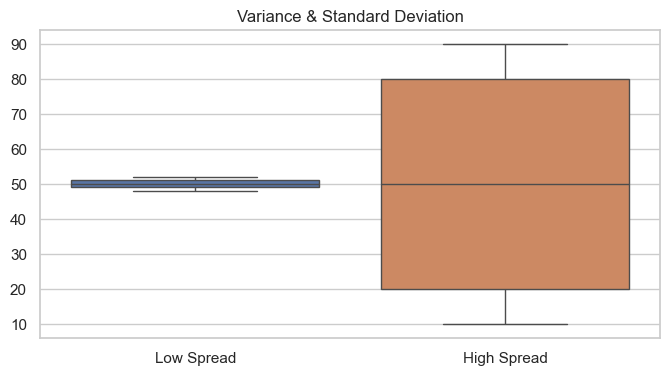

In [4]:
dataset1 = [50, 52, 48, 51, 49]   # low spread
dataset2 = [10, 90, 20, 80, 50]   # high spread

print("Dataset1 -> Mean:", np.mean(dataset1), "Std Dev:", np.std(dataset1))
print("Dataset2 -> Mean:", np.mean(dataset2), "Std Dev:", np.std(dataset2))

# Boxplots to visualize spread
plt.figure(figsize=(8,4))
sns.boxplot(data=[dataset1, dataset2])
plt.xticks([0,1], ["Low Spread", "High Spread"])
plt.title("Variance & Standard Deviation")
plt.show()

📢 **Observation**:  
- Both datasets have mean ~50.  
- But dataset2 is more “spread out” → higher variance.  

👉 **ML Insight**: Features with larger variance dominate distance-based models (KNN, SVM). That’s why we **scale features**!  

## 📌 Skewness & Kurtosis

Skewness: 1.8126349058731819
Kurtosis: 4.618741142860528


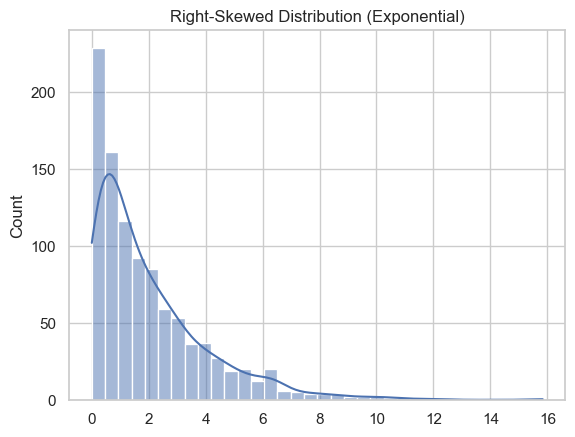

In [5]:
# Skewed dataset
data_skewed = np.random.exponential(scale=2, size=1000)

print("Skewness:", skew(data_skewed))
print("Kurtosis:", kurtosis(data_skewed))

sns.histplot(data_skewed, kde=True)
plt.title("Right-Skewed Distribution (Exponential)")
plt.show()

📢 **Observation**:  
- Skewness > 0 → Right-skewed (long right tail).  
- High kurtosis → “heavier tails” than normal.  

👉 **ML Insight**: Skewed features → Apply **log transform** before regression.  

## 📌 Outliers (IQR Method)

Detected outliers: [100]


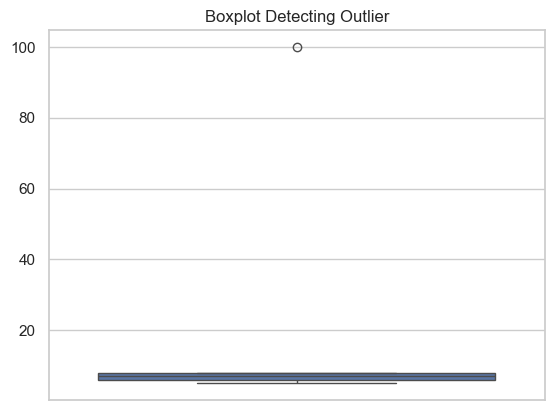

In [6]:
data_outliers = [5, 6, 7, 8, 100]  # 100 is an outlier

Q1 = np.percentile(data_outliers, 25)
Q3 = np.percentile(data_outliers, 75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = [x for x in data_outliers if x < lower or x > upper]

print("Detected outliers:", outliers)

sns.boxplot(data=data_outliers)
plt.title("Boxplot Detecting Outlier")
plt.show()

📢 **Observation**:  
- 100 is detected as an outlier.  

👉 **ML Insight**:  
- Linear Regression suffers from outliers.  
- Tree models (Random Forest, XGBoost) are **robust**.  

## 📌 Frequencies

Value: 0.5, Frequency: 10
Value: 1.5, Frequency: 10
Value: 2.5, Frequency: 10
Value: 3.5, Frequency: 9
Value: 4.5, Frequency: 17
Value: 5.5, Frequency: 8
Value: 6.5, Frequency: 10
Value: 7.5, Frequency: 17
Value: 8.5, Frequency: 9


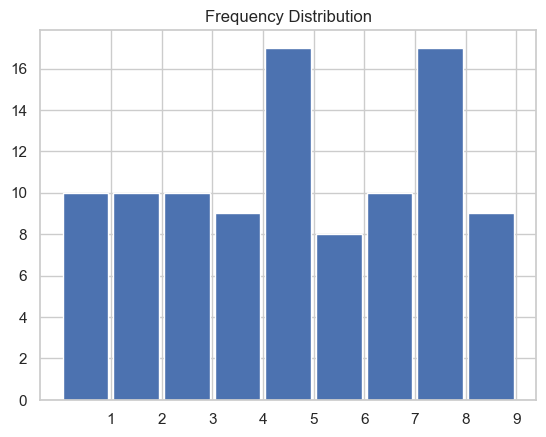

Values
1    10
2    10
3    10
4     9
5    17
6     8
7    10
8    17
9     9
Name: count, dtype: int64


In [ ]:
# Frequency distribution
data_freq = np.random.randint(1, 10, size=100)
freq, bins = np.histogram(data_freq, bins=np.arange(1, 11)-0.5)
plt.bar(bins[:-1], freq, width=0.9, align='center')

# Table of frequecies
for b, f in zip(bins[:-1], freq):
    print(f"Value: {b}, Frequency: {f}")
plt.xticks(range(1, 10))
plt.title("Frequency Distribution")
plt.show()

# Using pandas for frequency table Value Counts
import pandas as pd
df = pd.DataFrame(data_freq, columns=['Values'])
frequency_table = df['Values'].value_counts().sort_index()
print(frequency_table)





## 📌 Conditionnal Frequency

In [11]:
# Table of Conditional Frequency

data_cond = np.random.choice(['A', 'B', 'C'], size=100)
df_cond = pd.DataFrame(data_cond, columns=['Category'])
display(df_cond.head())
cond_freq_table = pd.crosstab(index=df_cond['Category'], columns='count')
cond_freq_table

,Category
0,B
1,A
2,A
3,B
4,A


col_0,count
Category,
A,29
B,37
C,34


**1. Préparer les données**<br>
Créez un DataFrame pandas pour l'exemple

In [12]:
import pandas as pd

data = {
    'Couleur': ['Rouge', 'Bleu', 'Rouge', 'Vert', 'Bleu', 'Rouge', 'Vert', 'Rouge', 'Bleu', 'Bleu'],
    'Forme': ['Rond', 'Carré', 'Carré', 'Rond', 'Rond', 'Rond', 'Carré', 'Rond', 'Carré', 'Rond']
}
df = pd.DataFrame(data)

print("DataFrame initial :")
print(df)

DataFrame initial :
  Couleur  Forme
0   Rouge   Rond
1    Bleu  Carré
2   Rouge  Carré
3    Vert   Rond
4    Bleu   Rond
5   Rouge   Rond
6    Vert  Carré
7   Rouge   Rond
8    Bleu  Carré
9    Bleu   Rond


**2. Calculer les fréquences conjointes**<br>
Par défaut, pd.crosstab() renvoie les effectifs conjoints. Pour obtenir les fréquences conjointes (pourcentages par rapport au total général), utilisez l'argument normalize='all'.

In [17]:
# Fréquences conjointes (par rapport au total)
frequences_conjointes = pd.crosstab(df['Couleur'], df['Forme'], normalize='all', margins=True)
print("\nFréquences conjointes :")
print(frequences_conjointes)


Fréquences conjointes :
Forme    Carré  Rond  All
Couleur                  
Bleu       0.2   0.2  0.4
Rouge      0.1   0.3  0.4
Vert       0.1   0.1  0.2
All        0.4   0.6  1.0


**Résultat :**
Le tableau affichera la proportion de chaque combinaison de Couleur et Forme par rapport au nombre total d'observations.

**3. Calculer les fréquences marginales**<br>
Pour afficher les fréquences marginales (les totaux des lignes et des colonnes), ajoutez l'argument margins=True à pd.crosstab().


In [16]:
# Fréquences conjointes et marginales (effectifs)
tableau_contingence = pd.crosstab(df['Couleur'], df['Forme'], margins=True)
print("\nTableau de contingence avec fréquences marginales (effectifs) :")
print(tableau_contingence)


Tableau de contingence avec fréquences marginales (effectifs) :
Forme    Carré  Rond  All
Couleur                  
Bleu         2     2    4
Rouge        1     3    4
Vert         1     1    2
All          4     6   10


**Résultat :**<br>
Les fréquences conjointes se trouvent dans le corps du tableau.
Les fréquences marginales sont affichées dans la colonne All (pour les lignes) et la ligne All (pour les colonnes). Le total général est à l'intersection.<br>

---

**4. Combiner les fréquences conjointes et marginales (en pourcentages)**<br>
Pour obtenir les fréquences conjointes et marginales exprimées en pourcentages, combinez les arguments margins=True et normalize=True

In [18]:
# Fréquences conjointes et marginales (pourcentages)
tableau_pourcentages = pd.crosstab(df['Couleur'], df['Forme'], normalize=True, margins=True)
print("\nTableau de contingence avec fréquences conjointes et marginales (pourcentages) :")
print(tableau_pourcentages)


Tableau de contingence avec fréquences conjointes et marginales (pourcentages) :
Forme    Carré  Rond  All
Couleur                  
Bleu       0.2   0.2  0.4
Rouge      0.1   0.3  0.4
Vert       0.1   0.1  0.2
All        0.4   0.6  1.0


**Résultat :**<br>
Les fréquences conjointes (pourcentages par rapport au total) sont dans le corps du tableau.
Les fréquences marginales (pourcentages par rapport au total) sont dans la ligne All et la colonne All. 
Options supplémentaires de pd.crosstab()<br>
**normalize='index' :**<br> Normalise les valeurs de chaque ligne pour qu'elles totalisent 1, montrant ainsi les fréquences conditionnelles des colonnes par rapport aux lignes.<br>
**normalize='columns' :**<br> Normalise les valeurs de chaque colonne pour qu'elles totalisent 1, montrant ainsi les fréquences conditionnelles des lignes par rapport aux colonnes.<br>
**aggfunc et values :**<br>Permet de calculer une fonction d'agrégation (comme la moyenne) sur une troisième variable, au lieu de compter les fréquences. 


# 🎯 Summary

- **Mean, Median, Mode** → tell us central tendency. Use **median** for skewed data.  
- **Variance & Std Dev** → measure spread. High variance = scattered data.  
- **Skewness & Kurtosis** → shape of distribution. Skewed → transformations may help.  
- **Outliers** → important to detect, can ruin models or be important signals.  

👉 In ML/DL: Statistics helps us **understand the story of our data** before modeling.  